# Appendix C: The Riemann-Roch Theorem

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix C, printed pp. 579-618; PDF pp. 594-633. Sections C.1-C.7 are used for coverage planning only.

**Appendix question.** Why does a Cauchy-Riemann type operator have an index controlled by topology, and how does that index change when boundaries, Maslov classes, gluing, or nonsmooth bundles enter? This appendix supplies much of the index bookkeeping used by the moduli-space chapters. The notebook translates that bookkeeping into inspectable models: closed-surface Riemann-Roch line-bundle indices, boundary Maslov winding, gluing additivity, proof dependencies, and a small almost-complex-structure check.

The chapter is proof-heavy, so the visual strategy is to expose invariants rather than simulate analysis. The reader should leave knowing which topological inputs enter the index formula, how Maslov winding modifies a boundary problem, why elliptic estimates support Fredholmness and regularity, and where Riemann mapping and local almost-complex coordinates fit into the proof architecture.


## Source Coverage

Section C.1 introduces complex linear and real Cauchy-Riemann operators on vector bundles, states Riemann-Roch, and records the Serre-duality relation. Section C.2 provides elliptic estimates needed for Fredholm control. Section C.3 adds boundary conditions and the Maslov index, including Arnold-style normalization and index formulas with boundary. Section C.4 proves Riemann-Roch through disk calculations and gluing additivity. Section C.5 supplies the Riemann mapping and local integrability tools used to normalize domains. Section C.6 explains why nonsmooth bundle data can still be handled. Section C.7 records almost-complex-structure lemmas used to move between local coordinates and bundle operators.

The notebook's coverage artifact records all seven source sections. Each section is paired with a computational representation: a closed index surface, a Maslov winding plot, a gluing ledger, a proof dependency graph, a Riemann-mapping coordinate scaffold, or an almost-complex matrix check.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "appendix-c"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Appendix C",
    "source_span_used": "printed pp. 579-618; PDF pp. 594-633",
    "sections": [
        {"section": "C.1", "focus": "Cauchy-Riemann operators, Riemann-Roch, Serre duality", "artifact": "riemann-roch-index-by-degree.png"},
        {"section": "C.2", "focus": "elliptic estimates for Fredholm and regularity control", "artifact": "riemann-roch-proof-map.png"},
        {"section": "C.3", "focus": "boundary Maslov index and Arnold normalization", "artifact": "maslov-boundary-winding.png"},
        {"section": "C.4", "focus": "disk index case and gluing proof of Riemann-Roch", "artifact": "gluing-index-additivity.png"},
        {"section": "C.5", "focus": "Riemann mapping and local conformal coordinates", "artifact": "riemann-mapping-coordinate-scaffold.png"},
        {"section": "C.6", "focus": "nonsmooth bundles and approximation-compatible operators", "artifact": "riemann-roch-ledger.csv"},
        {"section": "C.7", "focus": "almost complex structure lemmas", "artifact": "almost-complex-matrix-checks.json"},
    ],
    "copyright_boundary": "Original prose and generated diagrams only; no copied source text, exercises, or figures.",
}
library_routing = {
    "sympy": "Riemann-Roch and Maslov formulas are symbolic index identities",
    "matplotlib": "degree-index surfaces, winding paths, and gluing additivity are low-dimensional visual checks",
    "networkx": "the proof is a dependency chain from estimates through disk formulas and gluing",
    "pandas": "index cases and source coverage are stored as ledgers for auditing",
}
visual_storyboard = [
    {"visual": "riemann-roch-index-by-degree.png", "concept": "closed Riemann-Roch index", "inspection_target": "degree shifts the index while genus shifts the baseline", "invariant": "real index = 2(rank(1-g)+c1) for line examples"},
    {"visual": "maslov-boundary-winding.png", "concept": "boundary Maslov contribution", "inspection_target": "rotating Lagrangian line contributes a winding correction", "invariant": "Maslov index equals twice the winding in the model loop"},
    {"visual": "gluing-index-additivity.png", "concept": "index gluing", "inspection_target": "node matching subtracts the target dimension", "invariant": "glued index equals sum minus matching constraint"},
    {"visual": "riemann-roch-proof-map.png", "concept": "proof architecture", "inspection_target": "elliptic estimates and disk cases feed the general theorem", "invariant": "each source section has a proof-map node"},
    {"visual": "riemann-mapping-coordinate-scaffold.png", "concept": "coordinate normalization", "inspection_target": "domain normalization supports local operator comparison", "invariant": "J^2=-I and orientation determinant is positive"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/appendix-c/checks/visual-storyboard.json')

## Library Routing

Appendix C is an index appendix, so the chosen representations are formula-first. SymPy checks the exact identities for closed and boundary index formulas. Matplotlib turns those formulas into surfaces and winding diagrams that show how topology changes an operator's Fredholm index. NetworkX is used for the proof map because the appendix is not a single computation: elliptic estimates, disk cases, gluing, Riemann mapping, and almost-complex coordinate lemmas all feed the final theorem. Pandas records the cases a learner should be able to recompute by hand.

## Visualization Storyboard

First, plot the closed Riemann-Roch real index for line bundles over several genera and degrees. Second, visualize the Maslov index as a winding of boundary Lagrangian lines. Third, show gluing additivity by subtracting a node-matching constraint. Fourth, draw the proof map from operator estimates to the final theorem. Fifth, run a small almost-complex matrix check and an applied lab where rank, genus, Chern number, and Maslov index vary.


## 1. Closed Riemann-Roch as an Index Surface

For a complex rank `n` bundle over a closed genus `g` Riemann surface, the real Fredholm index of a Cauchy-Riemann operator is `n(2-2g)+2c1`. For a line bundle this is `2(deg + 1 - g)`. The figure plots that line-bundle formula across degrees and genera. The inspection target is the tradeoff: adding degree raises the index by two, while adding a handle lowers it by two. This is why the same analytic operator can have different moduli dimensions after changing topological data.


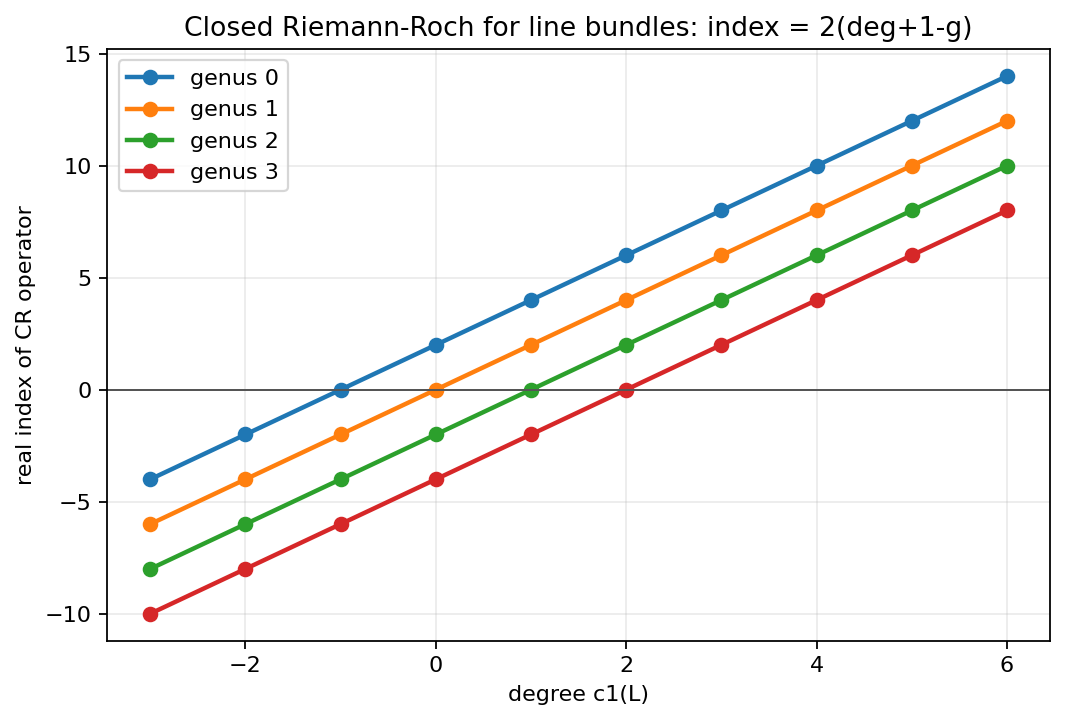

In [3]:
degrees = np.arange(-3, 7)
genera = np.arange(0, 4)
rows = []
for g in genera:
    for d in degrees:
        complex_index = d + 1 - g
        real_index = 2 * complex_index
        rows.append({"genus": int(g), "degree_c1": int(d), "complex_index": int(complex_index), "real_index": int(real_index)})
index_df = pd.DataFrame(rows)
index_df.to_csv(TABLE_DIR / "riemann-roch-ledger.csv", index=False)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for g in genera:
    subset = index_df[index_df["genus"] == g]
    ax.plot(subset["degree_c1"], subset["real_index"], marker="o", lw=2, label=f"genus {g}")
ax.axhline(0, color="#555", lw=0.9)
ax.set_xlabel("degree c1(L)")
ax.set_ylabel("real index of CR operator")
ax.set_title("Closed Riemann-Roch for line bundles: index = 2(deg+1-g)")
ax.legend()
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "riemann-roch-index-by-degree.png")
plt.close(fig)

n, g, c1 = sp.symbols("n g c1", integer=True)
formula = n * (2 - 2*g) + 2*c1
line_formula = sp.simplify(formula.subs(n, 1).subs(c1, sp.symbols("d")))
rr_checks = {
    "closed_real_index_formula": str(formula),
    "line_bundle_formula": str(line_formula),
    "degree_shift_real_index": int(index_df[(index_df.genus == 1) & (index_df.degree_c1 == 3)].real_index.iloc[0] - index_df[(index_df.genus == 1) & (index_df.degree_c1 == 2)].real_index.iloc[0]),
    "genus_shift_real_index": int(index_df[(index_df.genus == 2) & (index_df.degree_c1 == 1)].real_index.iloc[0] - index_df[(index_df.genus == 1) & (index_df.degree_c1 == 1)].real_index.iloc[0]),
    "passed": True,
}
rr_checks["passed"] = rr_checks["degree_shift_real_index"] == 2 and rr_checks["genus_shift_real_index"] == -2
tmp = save_json(rr_checks, UNIT, "checks", "riemann-roch-index-checks.json")
display_artifact(fig_path, width=760)


## 2. Boundary Maslov Index

Boundary value problems add a new topological input: a loop of totally real or Lagrangian boundary conditions. In the complex line model, rotating a real line through one full turn contributes Maslov index two. The plot shows a boundary line angle along the unit circle and records the winding. The corresponding index formula for a disk model has the form `n + Maslov`, so a rotating boundary condition can change the dimension even when the interior bundle is trivial.


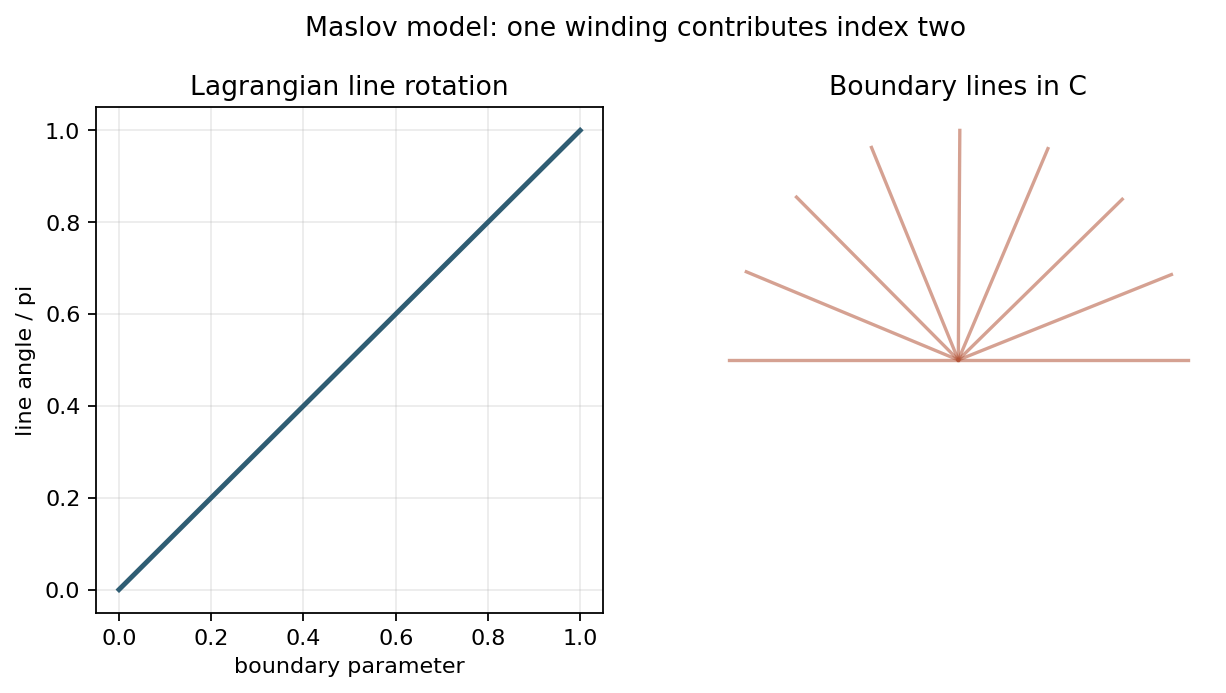

In [4]:
t = np.linspace(0, 1, 240)
winding = 1
angle = np.pi * winding * t
x = np.cos(angle)
y = np.sin(angle)
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.1))
axes[0].plot(t, angle / np.pi, color="#2f5d73", lw=2.2)
axes[0].set_xlabel("boundary parameter")
axes[0].set_ylabel("line angle / pi")
axes[0].set_title("Lagrangian line rotation")
axes[0].grid(alpha=0.25)
for idx in np.linspace(0, len(t)-1, 9, dtype=int):
    axes[1].plot([0, x[idx]], [0, y[idx]], color="#b45539", alpha=0.55)
axes[1].set_aspect("equal")
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title("Boundary lines in C")
axes[1].axis("off")
fig.suptitle("Maslov model: one winding contributes index two", y=1.02)
fig_path = save_matplotlib(fig, UNIT, "figures", "maslov-boundary-winding.png")
plt.close(fig)
maslov = 2 * winding
disk_rank = 1
disk_index = disk_rank + maslov
maslov_checks = {"winding": winding, "maslov_index": maslov, "disk_rank": disk_rank, "disk_index_rank_plus_maslov": disk_index, "passed": maslov == 2 and disk_index == 3}
save_json(maslov_checks, UNIT, "checks", "maslov-boundary-index-checks.json")
display_artifact(fig_path, width=880)


## 3. Gluing, Estimates, and the Proof Architecture

The proof of Riemann-Roch is not just a formula manipulation. Elliptic estimates give Fredholm control. Disk calculations establish base cases. Gluing compares indices before and after a node is matched, subtracting the dimension of the matching condition. Riemann mapping and local coordinate lemmas let the analytic problem be normalized. The following pair of visuals separates the numerical gluing check from the logical dependency graph.


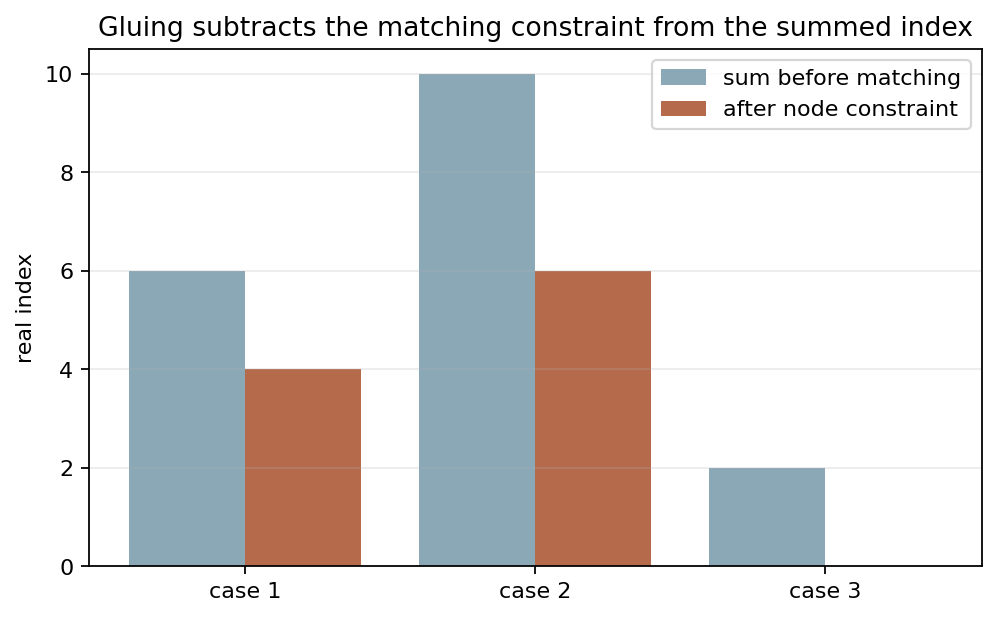

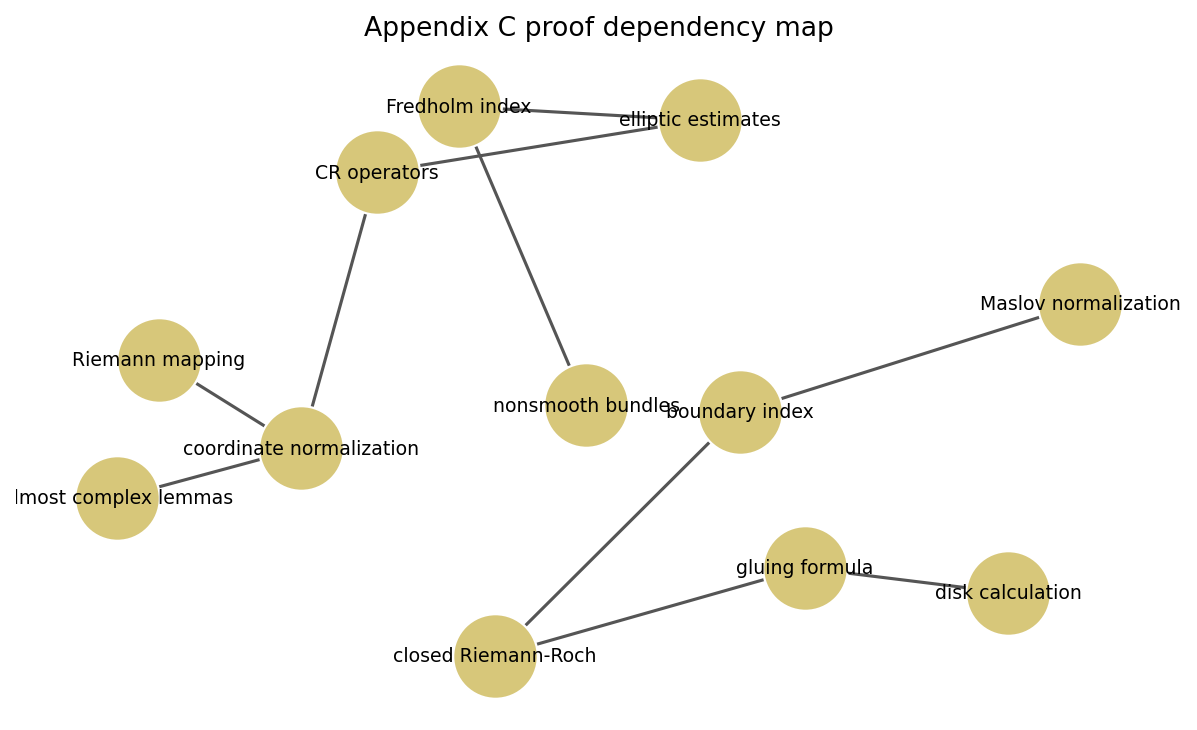

In [5]:
gluing_cases = pd.DataFrame([
    {"piece_A_index": 4, "piece_B_index": 2, "real_target_dim": 2, "expected_glued_index": 4, "description": "two line-bundle disk pieces matched at one target point"},
    {"piece_A_index": 6, "piece_B_index": 4, "real_target_dim": 4, "expected_glued_index": 6, "description": "rank-two pieces with one node-matching constraint"},
    {"piece_A_index": 0, "piece_B_index": 2, "real_target_dim": 2, "expected_glued_index": 0, "description": "boundary case with one neutral component"},
])
gluing_cases["computed_glued_index"] = gluing_cases["piece_A_index"] + gluing_cases["piece_B_index"] - gluing_cases["real_target_dim"]
gluing_cases["matches"] = gluing_cases["computed_glued_index"] == gluing_cases["expected_glued_index"]
gluing_cases.to_csv(TABLE_DIR / "gluing-index-additivity.csv", index=False)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
labels = ["case 1", "case 2", "case 3"]
xpos = np.arange(len(gluing_cases))
ax.bar(xpos - 0.2, gluing_cases["piece_A_index"] + gluing_cases["piece_B_index"], width=0.4, label="sum before matching", color="#8ba8b7")
ax.bar(xpos + 0.2, gluing_cases["computed_glued_index"], width=0.4, label="after node constraint", color="#b56b4b")
ax.set_xticks(xpos, labels)
ax.set_ylabel("real index")
ax.set_title("Gluing subtracts the matching constraint from the summed index")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "gluing-index-additivity.png")
plt.close(fig)

G = nx.DiGraph()
G.add_edges_from([
    ("CR operators", "elliptic estimates"),
    ("elliptic estimates", "Fredholm index"),
    ("disk calculation", "gluing formula"),
    ("Maslov normalization", "boundary index"),
    ("gluing formula", "closed Riemann-Roch"),
    ("boundary index", "closed Riemann-Roch"),
    ("Riemann mapping", "coordinate normalization"),
    ("almost complex lemmas", "coordinate normalization"),
    ("coordinate normalization", "CR operators"),
    ("nonsmooth bundles", "Fredholm index"),
])
pos = nx.spring_layout(G, seed=27, k=1.1)
fig, ax = plt.subplots(figsize=(9.4, 5.4))
nx.draw_networkx_nodes(G, pos, node_color="#d7c77a", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=14, edge_color="#555", width=1.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
ax.set_title("Appendix C proof dependency map")
ax.axis("off")
proof_path = save_matplotlib(fig, UNIT, "figures", "riemann-roch-proof-map.png")
plt.close(fig)
proof_checks = {"gluing_cases": int(len(gluing_cases)), "all_gluing_cases_match": bool(gluing_cases["matches"].all()), "proof_nodes": int(G.number_of_nodes()), "source_sections_represented": 7, "passed": bool(gluing_cases["matches"].all() and G.number_of_nodes() >= 9)}
save_json(proof_checks, UNIT, "checks", "riemann-roch-proof-checks.json")
display_artifact(fig_path, width=720)
display_artifact(proof_path, width=900)


## 4. Coordinate Normalization and Almost-Complex Checks

Riemann mapping and almost-complex-structure lemmas are easy to underestimate because they sit behind the index formula. They make local comparisons legal: domains can be normalized, operators can be put in standard form, and `J` must still satisfy `J^2=-I` with the correct orientation. The scaffold below is a small matrix check and a coordinate diagram; it records the part of the appendix that keeps the analytic formulas tied to genuine complex geometry.


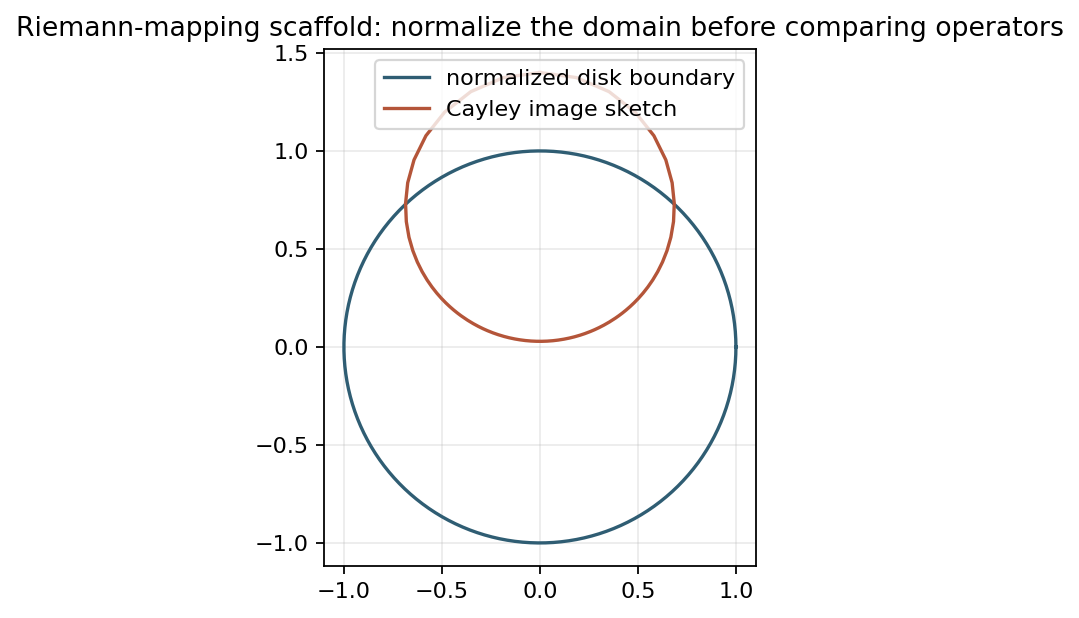

In [6]:
theta = np.linspace(0, 2*np.pi, 160)
unit_circle = np.c_[np.cos(theta), np.sin(theta)]
# A simple disk-to-half-plane style coordinate sketch via Cayley transform on the boundary, clipped for display.
z = 0.75 * np.exp(1j * theta)
w = 1j * (1 + z) / (1 - z)
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(unit_circle[:,0], unit_circle[:,1], color="#2f5d73", label="normalized disk boundary")
ax.plot(np.clip(w.real / 5, -2, 2), np.clip(w.imag / 5, -2, 2), color="#b45539", label="Cayley image sketch")
ax.set_aspect("equal")
ax.set_title("Riemann-mapping scaffold: normalize the domain before comparing operators")
ax.legend()
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "riemann-mapping-coordinate-scaffold.png")
plt.close(fig)

J = sp.Matrix([[0, -1], [1, 0]])
J_square = sp.simplify(J * J)
det_J = int(J.det())
coordinate_checks = {"J_squared": str(J_square), "determinant_J": det_J, "orientation_positive": det_J > 0, "passed": bool(J_square == -sp.eye(2) and det_J > 0)}
save_json(coordinate_checks, UNIT, "checks", "almost-complex-matrix-checks.json")
display_artifact(fig_path, width=760)


## Applied Lab

Use the formulas as a diagnostic panel. Choose a rank, genus, Chern number, and boundary Maslov index, then compare the closed and disk-style real indices. This lab intentionally mixes cases because the appendix's practical role is bookkeeping: when a moduli problem changes by adding a handle, changing Chern number, imposing a boundary condition, or gluing components, the index should change in the predicted direction before any transversality theorem is invoked.


In [7]:
lab_rows = []
for rank in [1, 2, 3]:
    for genus in [0, 1, 2]:
        for c1_value in [-1, 0, 2]:
            closed_index = rank * (2 - 2*genus) + 2*c1_value
            for maslov_value in [0, 2, 4]:
                disk_index = rank + maslov_value
                lab_rows.append({"rank": rank, "genus": genus, "c1": c1_value, "closed_real_index": closed_index, "maslov": maslov_value, "disk_model_index": disk_index})
lab = pd.DataFrame(lab_rows)
lab.to_csv(TABLE_DIR / "riemann-roch-index-lab.csv", index=False)
subset_c1 = lab[(lab["rank"] == 1) & (lab["genus"] == 1) & (lab["maslov"] == 0)].sort_values("c1")
subset_maslov = lab[(lab["rank"] == 2) & (lab["genus"] == 0) & (lab["c1"] == 0)].sort_values("maslov")
lab_checks = {
    "rows": int(len(lab)),
    "closed_index_step_minus1_to_0": int(subset_c1.iloc[1]["closed_real_index"] - subset_c1.iloc[0]["closed_real_index"]),
    "disk_index_changes_by_two_per_maslov_step": bool((subset_maslov["disk_model_index"].diff().dropna() == 2).all()),
    "has_negative_closed_index_cases": bool((lab["closed_real_index"] < 0).any()),
    "passed": True,
}
lab_checks["passed"] = lab_checks["closed_index_step_minus1_to_0"] == 2 and lab_checks["disk_index_changes_by_two_per_maslov_step"] and lab_checks["has_negative_closed_index_cases"]
save_json(lab_checks, UNIT, "checks", "riemann-roch-lab-checks.json")
lab.head(10)


,rank,genus,c1,closed_real_index,maslov,disk_model_index
0,1,0,-1,0,0,1
1,1,0,-1,0,2,3
2,1,0,-1,0,4,5
3,1,0,0,2,0,1
4,1,0,0,2,2,3
5,1,0,0,2,4,5
6,1,0,2,6,0,1
7,1,0,2,6,2,3
8,1,0,2,6,4,5
9,1,1,-1,-2,0,1


## Takeaways

- Riemann-Roch turns a Cauchy-Riemann operator's Fredholm index into topological data: rank, Euler characteristic, and first Chern number.
- Boundary value problems need a Maslov term. In the line model, one winding contributes Maslov index two.
- Gluing is index bookkeeping with a matching constraint; adding component indices without subtracting the target matching dimension overcounts.
- Elliptic estimates, Riemann mapping, nonsmooth-bundle approximations, and almost-complex coordinate lemmas are the analytic infrastructure that lets the topological formula apply to the operators used in the main text.
- Before using a moduli-space dimension formula, compute the index panel first and only then ask for transversality or compactness.


## Final Sanity Checks

The final cell checks that the appendix is not just prose: source coverage, library routing, storyboard, index plots, Maslov winding, gluing ledger, proof map, coordinate scaffold, and applied lab all have artifacts and JSON checks. It also reloads the checks to verify the core formulas: degree changes the closed real index by two, a Maslov winding of one contributes two, gluing subtracts the node constraint, and the standard complex matrix satisfies `J^2=-I`.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "riemann-roch-index-checks.json",
    CHECK_DIR / "maslov-boundary-index-checks.json",
    CHECK_DIR / "riemann-roch-proof-checks.json",
    CHECK_DIR / "almost-complex-matrix-checks.json",
    CHECK_DIR / "riemann-roch-lab-checks.json",
    FIG_DIR / "riemann-roch-index-by-degree.png",
    FIG_DIR / "maslov-boundary-winding.png",
    FIG_DIR / "gluing-index-additivity.png",
    FIG_DIR / "riemann-roch-proof-map.png",
    FIG_DIR / "riemann-mapping-coordinate-scaffold.png",
    TABLE_DIR / "riemann-roch-ledger.csv",
    TABLE_DIR / "gluing-index-additivity.csv",
    TABLE_DIR / "riemann-roch-index-lab.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "riemann-roch-index-by-degree.png")
assert_artifact(FIG_DIR / "maslov-boundary-winding.png")

check_names = ["riemann-roch-index-checks.json", "maslov-boundary-index-checks.json", "riemann-roch-proof-checks.json", "almost-complex-matrix-checks.json", "riemann-roch-lab-checks.json"]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "closed_degree_step_two": checks[0]["degree_shift_real_index"] == 2,
    "maslov_winding_two": checks[1]["maslov_index"] == 2,
    "gluing_cases_match": checks[2]["all_gluing_cases_match"],
    "almost_complex_matrix_ok": checks[3]["passed"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 16,
 'all_json_checks_passed': True,
 'closed_degree_step_two': True,
 'maslov_winding_two': True,
 'gluing_cases_match': True,
 'almost_complex_matrix_ok': True,
 'passed': True}